In [ ]:
import pandas as pd


sdud_df = pd.read_csv(
    "../processed/2025-12-18-SDUDmonthly.csv",
    dtype={"ndc11": str}
)

# Create ndc9 by removing the last 2 digits
sdud_df["ndc9"] = sdud_df["ndc11"].str[:-2]

In [23]:
sdud_df.columns

Index(['year', 'month', 'quarter', 'ndc11', 'units_reimbursed',
       'num_prescriptions', 'total_amount_reimbursed',
       'medicaid_amount_reimbursed', 'non_medicaid_amount_reimbursed',
       'month_start', 'ndc9'],
      dtype='object')

In [15]:
linkdage_df = pd.read_excel("linkdage_data.xlsx")

In [19]:
# Make sure the column is treated as text
linkdage_df["DailyMed Friendly"] = linkdage_df["DailyMed Friendly"].astype(str)

# Split into the two parts
parts = linkdage_df["DailyMed Friendly"].str.split("-", expand=True)

# Pad first part to 5 digits, second part to 4 digits, then concatenate
linkdage_df["ndc9"] = (
    parts[0].str.zfill(5) +
    parts[1].str.zfill(4)
)

In [20]:
linkdage_df

,DailyMed Friendly,FEI,Old FEI,Same? (Old and New),How did you find?,Found in Propublica,Propublica Status,FEI Count,Facility Distance (km),Notes,ndc9
0,71093-132,3008298016,3008298016,Yes,DUNS Table,1,Correct,Single - Both,NaN,NaN,710930132
1,62037-571,Not Found,Not Found,Yes,Issue,0,Not Available,Not Applicable,NaN,No result in DailyMed for this NDC/ Cannot fin...,620370571
2,62037-577,Not Found,Not Found,Yes,Issue,0,Not Available,Not Applicable,NaN,No result in DailyMed for this NDC/ Cannot fin...,620370577
3,11788-037,3011922870,3011922870,Yes,DUNS Table,0,Not Available,Single - DailyMed,NaN,NaN,117880037
4,11788-038,3011922870,3011922870,Yes,DUNS Table,0,Not Available,Single - DailyMed,NaN,NaN,117880038
...,...,...,...,...,...,...,...,...,...,...,...
104,68682-018,3002806613,3002806613,Yes,DUNS Table,1,Correct,Single - Both,NaN,NaN,686820018
105,71205-884,3008298016,Not Found,No (Old can't find),DUNS Table,1,Correct (ProPublica has more FEIs),Multi FEI - Propublica,NaN,This is repacked NDC and it has source NDCs / ...,712050884
106,68012-004,3002806613,3002806613,Yes,DUNS Table,0,Not Available,Not Applicable,NaN,NaN,680120004
107,47335-305,3004561553,3002809586,No (Changed),DUNS Table,1,Correct,Single - Both,NaN,NaN,473350305


In [29]:
# Aggregate SDUD to the NDC level
sdud_summary = (
    sdud_df.groupby("ndc9", as_index=False)
    .agg(
        total_prescriptions=("num_prescriptions", "sum"),
        total_units=("units_reimbursed", "sum"),
        total_reimbursement=("total_amount_reimbursed", "sum"),
        medicaid_reimbursement=("medicaid_amount_reimbursed", "sum"),
        non_medicaid_reimbursement=("non_medicaid_amount_reimbursed", "sum"),
        first_month=("month_start", "min"),
        last_month=("month_start", "max")
    )
)

# Merge ONLY onto linkage_df
analysis_df = (
    linkdage_df
    .merge(sdud_summary, on="ndc9", how="left")
)

analysis_df["linked"] = analysis_df["FEI"] != "Not Found"

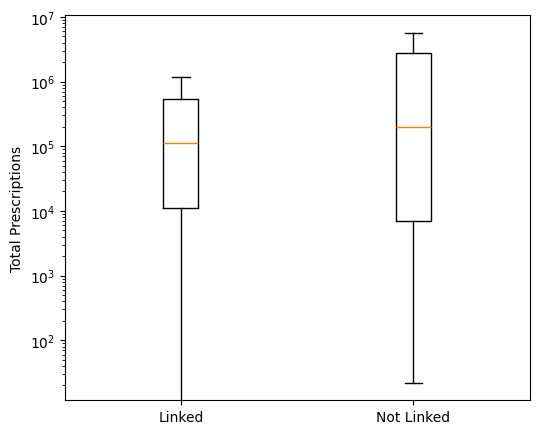

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.boxplot(
    [
        analysis_df.loc[analysis_df.linked, "total_prescriptions"].dropna(),
        analysis_df.loc[~analysis_df.linked, "total_prescriptions"].dropna()
    ],
    tick_labels=["Linked", "Not Linked"],
    showfliers=False
)

plt.yscale("log")
plt.ylabel("Total Prescriptions")
plt.show()

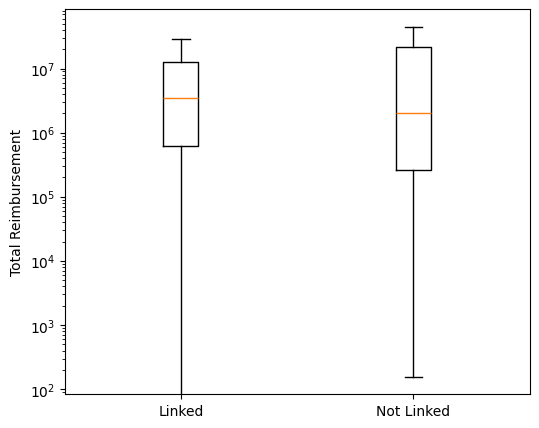

In [31]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        analysis_df.loc[analysis_df.linked, "total_reimbursement"].dropna(),
        analysis_df.loc[~analysis_df.linked, "total_reimbursement"].dropna()
    ],
    tick_labels=["Linked", "Not Linked"],
    showfliers=False
)

plt.yscale("log")
plt.ylabel("Total Reimbursement")
plt.show()

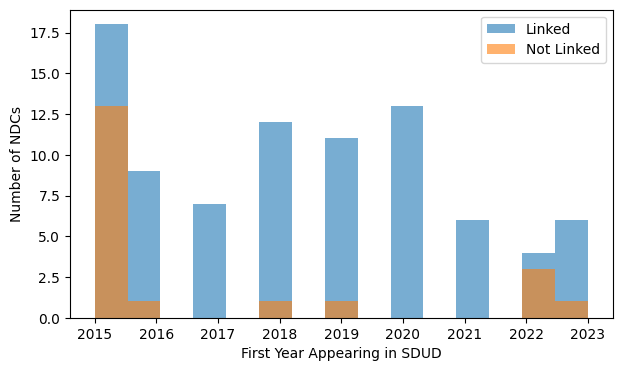

In [32]:
analysis_df["first_month"] = pd.to_datetime(analysis_df["first_month"])

plt.figure(figsize=(7,4))

plt.hist(
    analysis_df.loc[analysis_df.linked, "first_month"].dt.year.dropna(),
    alpha=.6,
    bins=15,
    label="Linked"
)

plt.hist(
    analysis_df.loc[~analysis_df.linked, "first_month"].dt.year.dropna(),
    alpha=.6,
    bins=15,
    label="Not Linked"
)

plt.xlabel("First Year Appearing in SDUD")
plt.ylabel("Number of NDCs")
plt.legend()

In [37]:
# Linkage status (one row per ndc9)
mapping = (
    linkdage_df[["ndc9", "FEI"]]
    .drop_duplicates(subset="ndc9")
    .copy()
)

mapping["linked"] = mapping["FEI"] != "Not Found"

# Keep only NDCs in linkage_df
plot_df = (
    sdud_df.merge(mapping, on="ndc9", how="inner")
)

plot_df["month_start"] = pd.to_datetime(plot_df["month_start"])

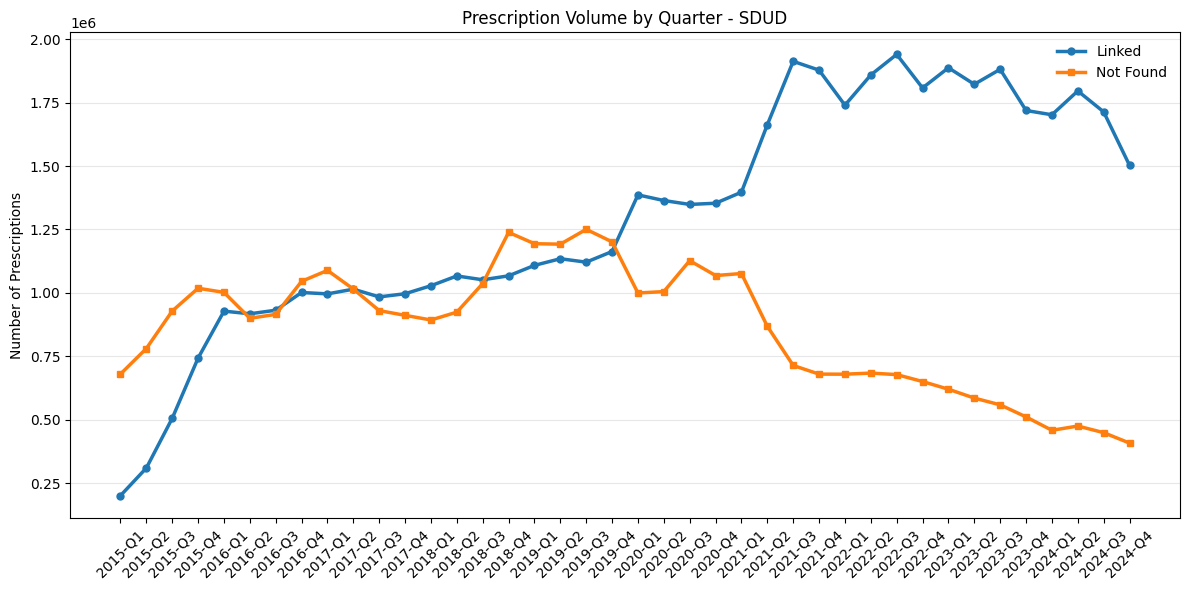

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Quarter label
plot_df["quarter_label"] = (
    plot_df["year"].astype(str) + "-Q" + plot_df["quarter"].astype(str)
)

quarterly = (
    plot_df
    .groupby(["year", "quarter", "quarter_label", "linked"])["num_prescriptions"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    quarterly["quarter_label"],
    quarterly[True],
    marker="o",
    linewidth=2.5,
    markersize=5,
    label="Linked"
)

plt.plot(
    quarterly["quarter_label"],
    quarterly[False],
    marker="s",
    linewidth=2.5,
    markersize=5,
    label="Not Found"
)

plt.ylabel("Number of Prescriptions")
plt.xlabel("")
plt.title("Prescription Volume by Quarter - SDUD")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

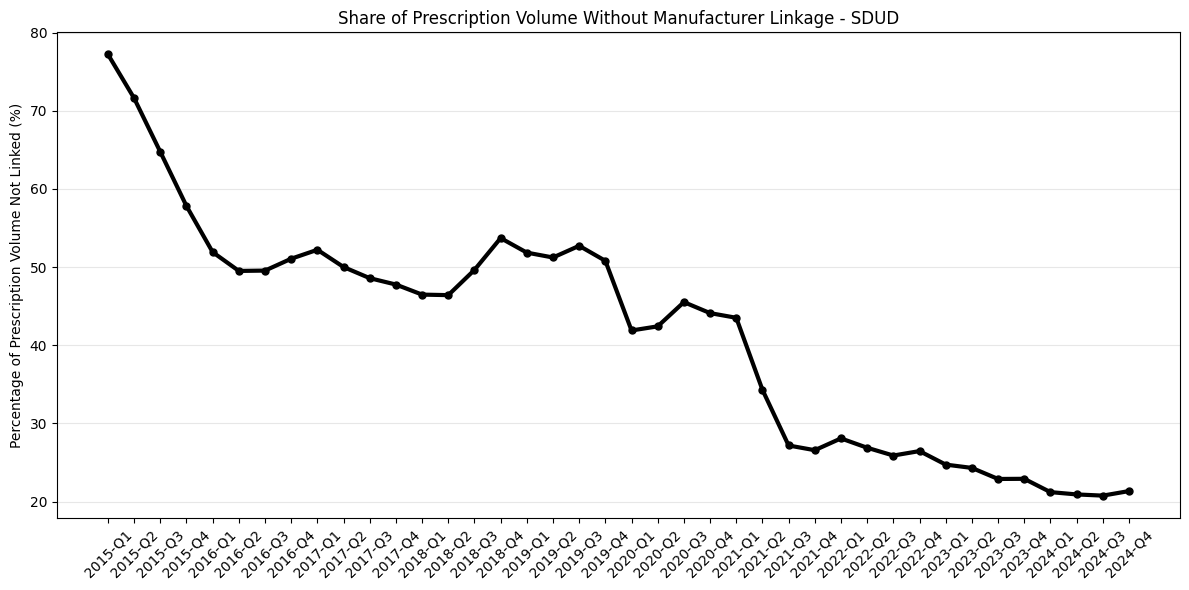

In [52]:
quarterly["pct_not_found"] = (
    quarterly[False] /
    (quarterly[True] + quarterly[False])
) * 100

plt.figure(figsize=(12,6))

plt.plot(
    quarterly["quarter_label"],
    quarterly["pct_not_found"],
    color="black",
    linewidth=3,
    marker="o",
    markersize=5
)

plt.ylabel("Percentage of Prescription Volume Not Linked (%)")
plt.xlabel("")
plt.title("Share of Prescription Volume Without Manufacturer Linkage - SDUD")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

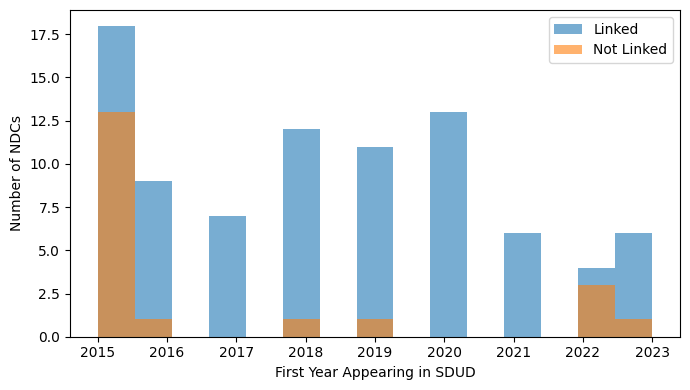


FIRST APPEARANCE YEAR SUMMARY

Linked
count      86.000000
mean     2018.255814
std         2.497933
min      2015.000000
25%      2016.000000
50%      2018.000000
75%      2020.000000
max      2023.000000
Name: first_month, dtype: float64

Not Linked
count      20.000000
mean     2016.850000
std         2.978431
min      2015.000000
25%      2015.000000
50%      2015.000000
75%      2018.250000
max      2023.000000
Name: first_month, dtype: float64

Counts by First Appearance Year
linked  Not Linked  Linked
year                      
2015.0          13      18
2016.0           1       9
2017.0           0       7
2018.0           1      12
2019.0           1      11
2020.0           0      13
2021.0           0       6
2022.0           3       4
2023.0           1       6

Percent Linked by First Appearance Year
year
2015.0     58.06
2016.0     90.00
2017.0    100.00
2018.0     92.31
2019.0     91.67
2020.0    100.00
2021.0    100.00
2022.0     57.14
2023.0     85.71
Name: Percent Li

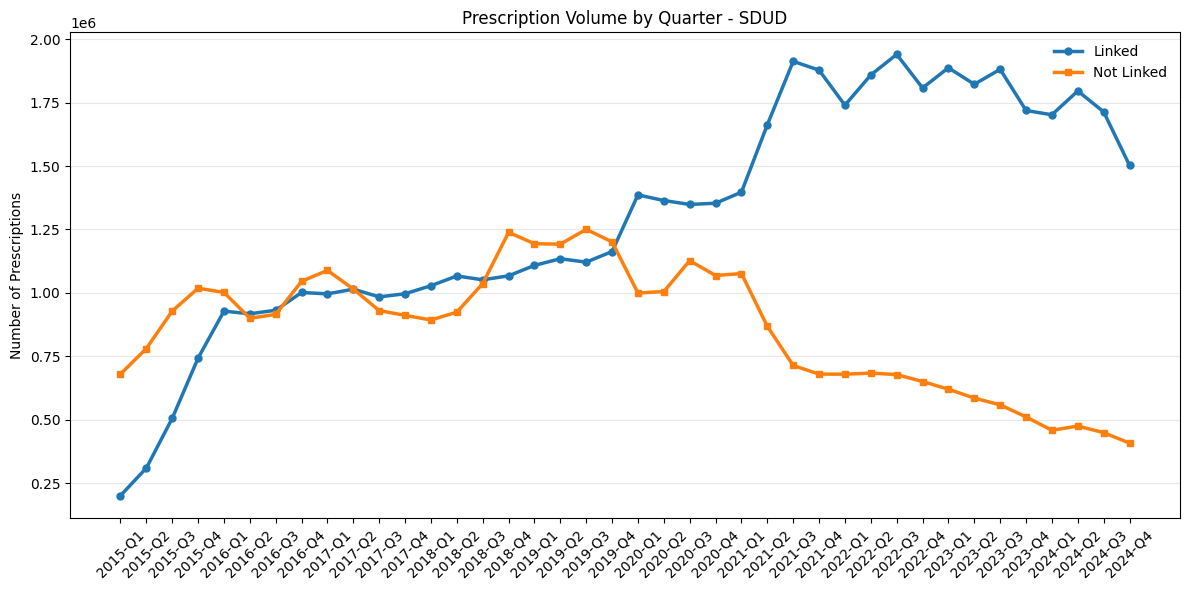


QUARTERLY PRESCRIPTION COUNTS
linked quarter_label     Linked  Not Linked
0            2015-Q1   200520.0    679963.0
1            2015-Q2   309371.0    780667.0
2            2015-Q3   505511.0    928479.0
3            2015-Q4   742924.0   1018300.0
4            2016-Q1   928003.0   1002030.0
5            2016-Q2   917580.0    899840.0
6            2016-Q3   931568.0    915220.0
7            2016-Q4  1001533.0   1045533.0
8            2017-Q1   996098.0   1088688.0
9            2017-Q2  1014600.0   1015096.0
10           2017-Q3   984190.0    930086.0
11           2017-Q4   996593.0    911471.0
12           2018-Q1  1028287.0    893106.0
13           2018-Q2  1066762.0    924056.0
14           2018-Q3  1051653.0   1036818.0
15           2018-Q4  1067189.0   1238607.0
16           2019-Q1  1108461.0   1193977.0
17           2019-Q2  1134700.0   1192050.0
18           2019-Q3  1121155.0   1250536.0
19           2019-Q4  1163119.0   1201228.0
20           2020-Q1  1386478.0    999599.0
2

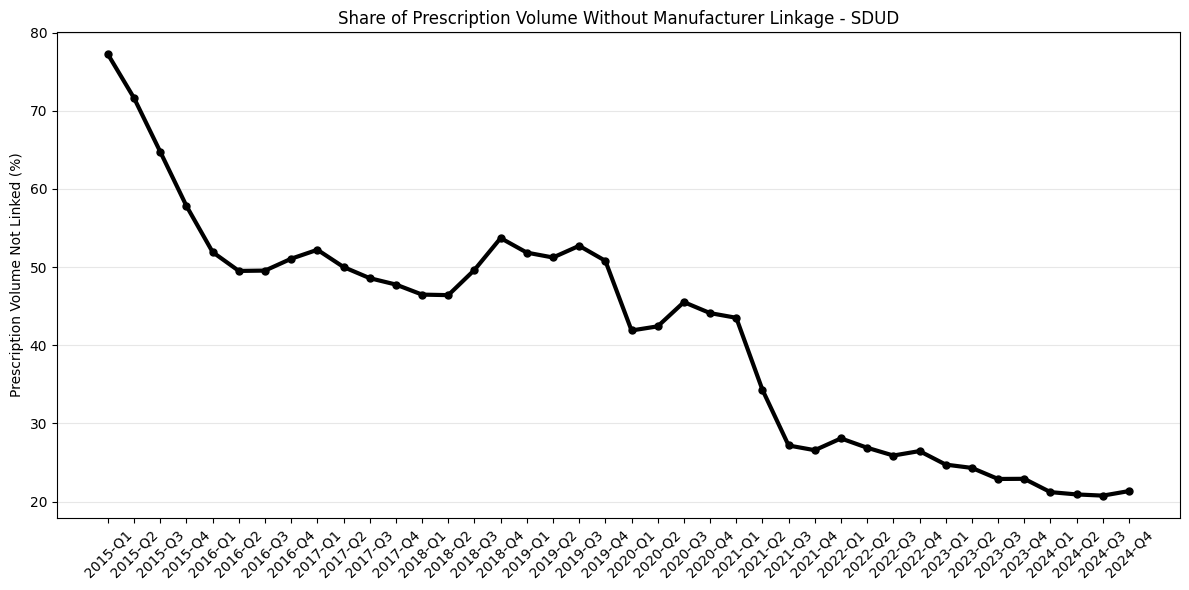


PERCENT NOT LINKED BY QUARTER
linked quarter_label     Linked  Not Linked  Percent Not Linked
0            2015-Q1   200520.0    679963.0               77.23
1            2015-Q2   309371.0    780667.0               71.62
2            2015-Q3   505511.0    928479.0               64.75
3            2015-Q4   742924.0   1018300.0               57.82
4            2016-Q1   928003.0   1002030.0               51.92
5            2016-Q2   917580.0    899840.0               49.51
6            2016-Q3   931568.0    915220.0               49.56
7            2016-Q4  1001533.0   1045533.0               51.07
8            2017-Q1   996098.0   1088688.0               52.22
9            2017-Q2  1014600.0   1015096.0               50.01
10           2017-Q3   984190.0    930086.0               48.59
11           2017-Q4   996593.0    911471.0               47.77
12           2018-Q1  1028287.0    893106.0               46.48
13           2018-Q2  1066762.0    924056.0               46.42
14       

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Figure 1: Distribution of First Appearance Year
# =====================================================

analysis_df["first_month"] = pd.to_datetime(analysis_df["first_month"])

linked_years = (
    analysis_df.loc[analysis_df["linked"], "first_month"]
    .dt.year
    .dropna()
)

notlinked_years = (
    analysis_df.loc[~analysis_df["linked"], "first_month"]
    .dt.year
    .dropna()
)

plt.figure(figsize=(7,4))

plt.hist(
    linked_years,
    bins=15,
    alpha=0.6,
    label="Linked"
)

plt.hist(
    notlinked_years,
    bins=15,
    alpha=0.6,
    label="Not Linked"
)

plt.xlabel("First Year Appearing in SDUD")
plt.ylabel("Number of NDCs")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# PRINT SUMMARY FOR FIGURE 1
# =====================================================

print("\n" + "="*60)
print("FIRST APPEARANCE YEAR SUMMARY")
print("="*60)

print("\nLinked")
print(linked_years.describe())

print("\nNot Linked")
print(notlinked_years.describe())

year_table = (
    analysis_df.assign(year=analysis_df["first_month"].dt.year)
    .groupby(["year", "linked"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in [True, False]:
    if col not in year_table.columns:
        year_table[col] = 0

year_table = year_table.rename(
    columns={
        True: "Linked",
        False: "Not Linked"
    }
)

print("\nCounts by First Appearance Year")
print(year_table)

year_table["Percent Linked"] = (
    year_table["Linked"] /
    (year_table["Linked"] + year_table["Not Linked"])
    * 100
).round(2)

print("\nPercent Linked by First Appearance Year")
print(year_table["Percent Linked"])


# =====================================================
# Figure 2: Quarterly Prescription Volume
# =====================================================

plot_df["quarter_label"] = (
    plot_df["year"].astype(str)
    + "-Q"
    + plot_df["quarter"].astype(str)
)

quarterly = (
    plot_df
    .groupby(
        ["year", "quarter", "quarter_label", "linked"]
    )["num_prescriptions"]
    .sum()
    .unstack(fill_value=0)
)

# Ensure both linkage columns exist
for col in [True, False]:
    if col not in quarterly.columns:
        quarterly[col] = 0

quarterly = (
    quarterly
    .rename(
        columns={
            True: "Linked",
            False: "Not Linked"
        }
    )
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    quarterly["quarter_label"],
    quarterly["Linked"],
    marker="o",
    linewidth=2.5,
    markersize=5,
    label="Linked"
)

plt.plot(
    quarterly["quarter_label"],
    quarterly["Not Linked"],
    marker="s",
    linewidth=2.5,
    markersize=5,
    label="Not Linked"
)

plt.ylabel("Number of Prescriptions")
plt.xlabel("")
plt.title("Prescription Volume by Quarter - SDUD")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

# =====================================================
# PRINT SUMMARY FOR FIGURE 2
# =====================================================

print("\n" + "="*60)
print("QUARTERLY PRESCRIPTION COUNTS")
print("="*60)

print(
    quarterly[
        [
            "quarter_label",
            "Linked",
            "Not Linked"
        ]
    ]
)

print("\nOverall Totals")
print(
    quarterly[
        [
            "Linked",
            "Not Linked"
        ]
    ].sum()
)

print("\nLinked Share (%)")
linked_share = (
    quarterly["Linked"] /
    (
        quarterly["Linked"]
        + quarterly["Not Linked"]
    )
    * 100
).round(2)

print(
    pd.DataFrame({
        "Quarter": quarterly["quarter_label"],
        "Linked %": linked_share
    })
)


# =====================================================
# Figure 3: Percentage Not Linked
# =====================================================

quarterly["Percent Not Linked"] = (
    quarterly["Not Linked"] /
    (
        quarterly["Linked"]
        + quarterly["Not Linked"]
    )
    * 100
)

plt.figure(figsize=(12,6))

plt.plot(
    quarterly["quarter_label"],
    quarterly["Percent Not Linked"],
    color="black",
    linewidth=3,
    marker="o",
    markersize=5
)

plt.ylabel("Prescription Volume Not Linked (%)")
plt.xlabel("")
plt.title("Share of Prescription Volume Without Manufacturer Linkage - SDUD")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# PRINT SUMMARY FOR FIGURE 3
# =====================================================

print("\n" + "="*60)
print("PERCENT NOT LINKED BY QUARTER")
print("="*60)

print(
    quarterly[
        [
            "quarter_label",
            "Linked",
            "Not Linked",
            "Percent Not Linked"
        ]
    ].round(2)
)

print("\nSummary Statistics")
print(
    quarterly["Percent Not Linked"]
    .describe()
    .round(2)
)

print("\nHighest 10 Quarters")
print(
    quarterly.nlargest(
        10,
        "Percent Not Linked"
    )[
        [
            "quarter_label",
            "Percent Not Linked"
        ]
    ].round(2)
)

print("\nLowest 10 Quarters")
print(
    quarterly.nsmallest(
        10,
        "Percent Not Linked"
    )[
        [
            "quarter_label",
            "Percent Not Linked"
        ]
    ].round(2)
)

print("\nYearly Summary")
yearly = (
    quarterly
    .groupby("year")[["Linked", "Not Linked"]]
    .sum()
)

yearly["Percent Not Linked"] = (
    yearly["Not Linked"] /
    (
        yearly["Linked"]
        + yearly["Not Linked"]
    )
    * 100
).round(2)

print(yearly)